# Early Diabetes Prediction Framework Using Health-Related & Symptom-Based Features

**Department of CSE (Data Science)**  
**Course:** Statistical Machine Learning for Data Science  
**Project Title:** Machine Learning Framework for Early Stage Diabetes Risk Prediction  
**Environment:** VS Code & Jupyter Notebook  

---

## Dataset Description

This project utilizes a clinical and symptom-based dataset designed for early-stage diabetes detection. Each record represents a patient profile comprising demographic information, early diagnostic symptoms, and core physiological/metabolic parameters.

The dataset includes the following key attributes:
* **`Age`**: Patient age in years.
* **`Gender`**: Patient gender (`Male` / `Female`).
* **`Polyuria`**: Presence of frequent/excessive urination (`Yes` / `No`).
* **`Polydipsia`**: Presence of excessive thirst (`Yes` / `No`).
* **`Sudden_Weight_Loss`**: Unexplained rapid weight loss (`Yes` / `No`).
* **`Weakness`**: Generalized physical fatigue or weakness (`Yes` / `No`).
* **`Polyphagia`**: Excessive or uncharacteristic hunger (`Yes` / `No`).
* **`Genital_Thrush`**: Occurrence of genital thrush fungal infection (`Yes` / `No`).
* **`Visual_Blurring`**: Blurring or impairment of visual acuity (`Yes` / `No`).
* **`Itching`**: Persistent skin itching/pruritus (`Yes` / `No`).
* **`Irritability`**: Sudden mood shifts or irritability (`Yes` / `No`).
* **`Delayed_Healing`**: Prolonged healing time for minor cuts/wounds (`Yes` / `No`).
* **`Partial_Paresis`**: Partial muscle weakness or loss of voluntary movement (`Yes` / `No`).
* **`Muscle_Stiffness`**: Localized or generalized muscle stiffness (`Yes` / `No`).
* **`Alopecia`**: Sudden or patchy hair loss (`Yes` / `No`).
* **`Obesity`**: Obese body classification marker (`Yes` / `No`).
* **`Glucose_Level`**: Fasting blood glucose concentration in mg/dL.
* **`BMI`**: Body Mass Index in kg/m².
* **`Systolic_BP`**: Systolic blood pressure in mmHg.
* **`Diabetes_Pedigree`**: Genetic diabetes pedigree score measuring family history influence.
* **`Class`**: Diagnostic binary outcome (`1` = Diabetes Positive / High Risk, `0` = Diabetes Negative / Low Risk).

---

## Abstract

This project presents a comprehensive Machine Learning Framework for modeling early diabetes risk using a dual-modality approach combining health-related metabolic biometrics and early clinical symptoms. Early stage diabetes mellitus often manifests through subtle physiological changes and symptom patterns prior to severe vascular damage. Here, we leverage **9 classification algorithms** (*Logistic Regression, Support Vector Machine, Random Forest, Gradient Boosting, XGBoost, Decision Tree, K-Nearest Neighbors, Naive Bayes, Multi-Layer Perceptron*) to model disease risk probabilities. Data preprocessing involves binary mapping, missing value verification, standard feature scaling, and stratified train-test partitioning. Comprehensive Exploratory Data Analysis (EDA) elucidates correlation structures and symptom prevalence differentials between patient cohorts. Model evaluation employs 5-Fold Stratified Cross-Validation, ROC-AUC curve analysis, Precision-Recall metrics, and Confusion Matrix inspections. A baseline predictor is constructed for comparative validation. Furthermore, an interactive Diagnostic Risk Predictor engine is deployed to compute continuous patient risk scores (0-100%), risk tiers (Low, Moderate, High), and actionable clinical recommendations.

**Keywords:** Early Diabetes Prediction, Machine Learning, Statistical Learning, Feature Scaling, Classification Benchmarking, ROC-AUC, Symptom Analysis, Health Informatics, Risk Assessment Engine, Data Science.


## 1. Introduction

Diabetes mellitus is a chronic metabolic disorder characterized by persistent hyperglycemia resulting from defects in insulin secretion, insulin action, or both. Unmanaged early-stage diabetes rapidly progresses to systemic microvascular and macrovascular complications, including diabetic retinopathy, nephropathy, peripheral neuropathy, and ischemic heart disease.

Early screening and predictive risk modeling are vital for enabling timely clinical intervention, lifestyle modification, and glycemic management. Traditional diagnostic procedures rely primarily on lab-based fasting blood glucose tests or oral glucose tolerance tests, which may not capture early subtle symptom manifestations. By synthesizing physiological metrics (*Fasting Glucose, BMI, Blood Pressure, Pedigree Score*) alongside self-reported early clinical symptoms (*Polyuria, Polydipsia, Weight Loss, Polyphagia*), machine learning algorithms can detect complex non-linear disease patterns and provide automated, non-invasive early risk stratifications.


## 2. Problem Statement

The primary challenge addressed in this project is the accurate early-stage identification of diabetes risk using multidimensional clinical and symptom data. Existing healthcare diagnostic workflows often encounter bottlenecks due to delayed clinical visits, silent symptom progression, and single-variable screening thresholds.

Existing challenges include:
* **Complex Multi-Feature Dependencies:** How can we model non-linear interactions between metabolic biometrics and clinical symptom markers?
* **Early Risk Quantification:** Can we compute a continuous, reliable risk score (0-100%) that stratifies patients into actionable risk tiers (Low, Moderate, High)?
* **Algorithm Selection & Generalization:** Which classification architecture achieves optimal trade-offs between Sensitivity (Recall for true positives) and Overall Precision?
* **Model Validation Against Baselines:** Does advanced machine learning significantly outperform naive baseline predictors?


## 3. Objectives

This project aims to achieve the following specific objectives:

1. **Dataset Loading & Preprocessing:** Load clinical patient records, verify missing values, remove redundant entries, encode categorical symptoms, and scale numerical variables using `StandardScaler`.
2. **Exploratory Data Analysis (EDA):** Perform quantitative and visual EDA to analyze target class balance, symptom prevalence rates between diabetic cohorts, fasting glucose/BMI distributions, and feature correlation heatmaps.
3. **Stratified Partitioning:** Execute a stratified 80/20 train-test split to preserve diagnostic outcome ratios across training and evaluation sets.
4. **Multi-Algorithm Training:** Train and benchmark 9 machine learning classifiers (*Logistic Regression, SVM, Random Forest, Gradient Boosting, XGBoost, Decision Tree, KNN, Naive Bayes, MLP Neural Net*).
5. **Cross-Validation & ROC-AUC Analysis:** Evaluate model stability using 5-Fold Stratified Cross-Validation and compute Receiver Operating Characteristic (ROC) curves.
6. **Baseline Model Comparison:** Build a majority-class baseline model to empirically demonstrate the predictive lift of machine learning models.
7. **Diagnostic Risk Engine:** Implement a reusable patient risk scoring engine that outputs continuous risk probability, risk category, and clinical guidance.


## 4. Research Questions

This study addresses the following core research questions:

1. **Symptom Discriminative Power:** Which early clinical symptoms exhibit the highest prevalence differential between diabetes-positive and diabetes-negative patients?
2. **Predictive Performance:** Which classification algorithm yields the highest F1-Score, Sensitivity (Recall), and ROC-AUC on unseen clinical test data?
3. **Statistical Lift over Baseline:** Does machine learning provide a statistically significant improvement in prediction accuracy compared to a naive majority-class baseline?
4. **Risk Quantification:** How effectively can continuous probability outputs be mapped to actionable clinical risk tiers?


In [1]:
# 5. Import Essential Data Science & Machine Learning Libraries
import os
import random
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Set random seeds for strict reproducibility
np.random.seed(42)
random.seed(42)

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', palette='muted')

# Machine Learning & Evaluation Libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

# Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# 6. Dataset Loading & Validation
dataset_path = 'diabetes_data.csv'

if not os.path.exists(dataset_path):
    from generate_dataset import generate_diabetes_dataset
    df = generate_diabetes_dataset(n_samples=1200, random_state=42)
    df.to_csv(dataset_path, index=False)
    print(f"Dataset generated with shape {df.shape} and saved to '{dataset_path}'.")
else:
    df = pd.read_csv(dataset_path)
    print(f"Dataset loaded successfully. Total Records: {df.shape[0]}, Total Features: {df.shape[1]}")


Dataset loaded successfully. Total Records: 1200, Total Features: 21


In [3]:
# 7. Data Inspection
print("### Dataset Head (First 5 Records) ###")
display(df.head())

print("\n### Dataset Summary Info ###")
df.info()

print("\n### Quantitative Feature Statistics ###")
display(df.describe(include='all'))


### Dataset Head (First 5 Records) ###


,Age,Gender,Polyuria,Polydipsia,Sudden_Weight_Loss,Weakness,Polyphagia,Genital_Thrush,Visual_Blurring,Itching,Irritability,Delayed_Healing,Partial_Paresis,Muscle_Stiffness,Alopecia,Obesity,Glucose_Level,BMI,Systolic_BP,Diabetes_Pedigree,Class
0,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,143.5,36.6,124.0,1.398,1
1,71,Male,Yes,Yes,No,Yes,Yes,No,No,Yes,No,No,No,Yes,No,No,115.3,20.2,155.0,0.454,1
2,48,Female,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,No,No,No,124.8,23.6,112.0,1.719,1
3,34,Female,No,No,No,Yes,Yes,No,No,No,No,Yes,No,No,No,Yes,102.0,31.4,120.0,0.816,0
4,62,Male,Yes,No,No,Yes,No,No,No,No,No,Yes,No,No,No,No,70.0,29.8,122.0,0.095,1



### Dataset Summary Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1200 non-null   int64  
 1   Gender              1200 non-null   object 
 2   Polyuria            1200 non-null   object 
 3   Polydipsia          1200 non-null   object 
 4   Sudden_Weight_Loss  1200 non-null   object 
 5   Weakness            1200 non-null   object 
 6   Polyphagia          1200 non-null   object 
 7   Genital_Thrush      1200 non-null   object 
 8   Visual_Blurring     1200 non-null   object 
 9   Itching             1200 non-null   object 
 10  Irritability        1200 non-null   object 
 11  Delayed_Healing     1200 non-null   object 
 12  Partial_Paresis     1200 non-null   object 
 13  Muscle_Stiffness    1200 non-null   object 
 14  Alopecia            1200 non-null   object 
 15  Obesity             1200 

,Age,Gender,Polyuria,Polydipsia,Sudden_Weight_Loss,Weakness,Polyphagia,Genital_Thrush,Visual_Blurring,Itching,Irritability,Delayed_Healing,Partial_Paresis,Muscle_Stiffness,Alopecia,Obesity,Glucose_Level,BMI,Systolic_BP,Diabetes_Pedigree,Class
count,1200.000000,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
unique,NaN,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,NaN,NaN,NaN,NaN,NaN
top,NaN,Female,Yes,Yes,No,Yes,No,No,No,No,No,No,No,No,No,No,NaN,NaN,NaN,NaN,NaN
freq,NaN,602,726,717,604,652,604,804,697,684,791,724,834,726,847,671,NaN,NaN,NaN,NaN,NaN
mean,47.210000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.241250,27.963583,121.742500,0.483445,0.494167
std,15.965953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.512049,5.876279,15.062988,0.380907,0.500174
min,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.000000,16.000000,90.000000,0.081000,0.000000
25%,34.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.900000,24.000000,111.000000,0.207000,0.000000
50%,47.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118.450000,28.000000,122.000000,0.373000,0.000000
75%,61.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,145.225000,31.825000,132.000000,0.653000,1.000000


In [4]:
# 8. Data Preprocessing: Missing Values, Duplicates, and Encoding
print("### 8.1 Missing Value Inspection ###")
missing_count = df.isnull().sum().sum()
print(f"Total Missing Values: {missing_count}")

print("\n### 8.2 Duplicate Entry Checking ###")
dup_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {dup_count}")

print("\n### 8.3 Categorical Feature Encoding & Standardization ###")
data = df.copy()

binary_symptom_cols = [
    'Polyuria', 'Polydipsia', 'Sudden_Weight_Loss', 'Weakness', 'Polyphagia',
    'Genital_Thrush', 'Visual_Blurring', 'Itching', 'Irritability',
    'Delayed_Healing', 'Partial_Paresis', 'Muscle_Stiffness', 'Alopecia', 'Obesity'
]

for col in binary_symptom_cols:
    data[col] = data[col].map({'Yes': 1, 'No': 0, 1: 1, 0: 0})
    
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})

print("Categorical features encoded to binary integers (1/0).")
display(data.head())


### 8.1 Missing Value Inspection ###
Total Missing Values: 0

### 8.2 Duplicate Entry Checking ###
Total Duplicate Rows: 0

### 8.3 Categorical Feature Encoding & Standardization ###


Categorical features encoded to binary integers (1/0).


,Age,Gender,Polyuria,Polydipsia,Sudden_Weight_Loss,Weakness,Polyphagia,Genital_Thrush,Visual_Blurring,Itching,Irritability,Delayed_Healing,Partial_Paresis,Muscle_Stiffness,Alopecia,Obesity,Glucose_Level,BMI,Systolic_BP,Diabetes_Pedigree,Class
0,58,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,143.5,36.6,124.0,1.398,1
1,71,1,1,1,0,1,1,0,0,1,0,0,0,1,0,0,115.3,20.2,155.0,0.454,1
2,48,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,124.8,23.6,112.0,1.719,1
3,34,0,0,0,0,1,1,0,0,0,0,1,0,0,0,1,102.0,31.4,120.0,0.816,0
4,62,1,1,0,0,1,0,0,0,0,0,1,0,0,0,0,70.0,29.8,122.0,0.095,1


In [5]:
# 9. Feature Selection & Stratified Train/Test Split
X = data.drop(columns=['Class'])
y = data['Class']

num_cols = ['Age', 'Glucose_Level', 'BMI', 'Systolic_BP', 'Diabetes_Pedigree']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

feature_names = list(X.columns)

print(f"Training Set Shape: {X_train_scaled.shape}")
print(f"Testing Set Shape:  {X_test_scaled.shape}")
print("Class Distribution in Training Set:\n", y_train.value_counts(normalize=True))


Training Set Shape: (960, 20)
Testing Set Shape:  (240, 20)
Class Distribution in Training Set:
 Class
0    0.50625
1    0.49375
Name: proportion, dtype: float64


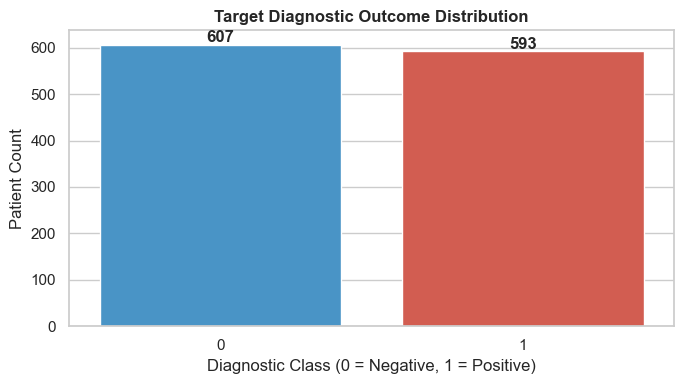

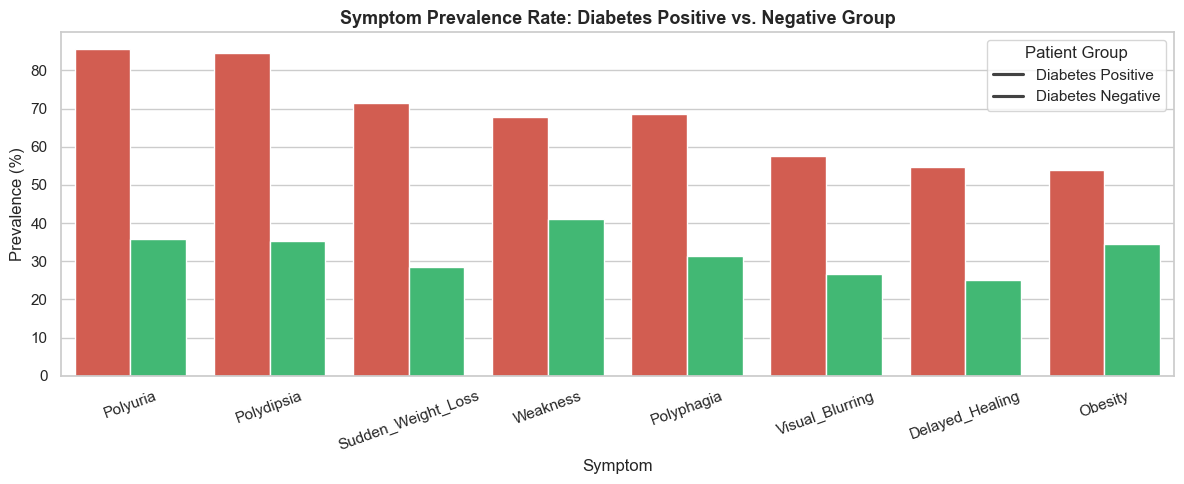

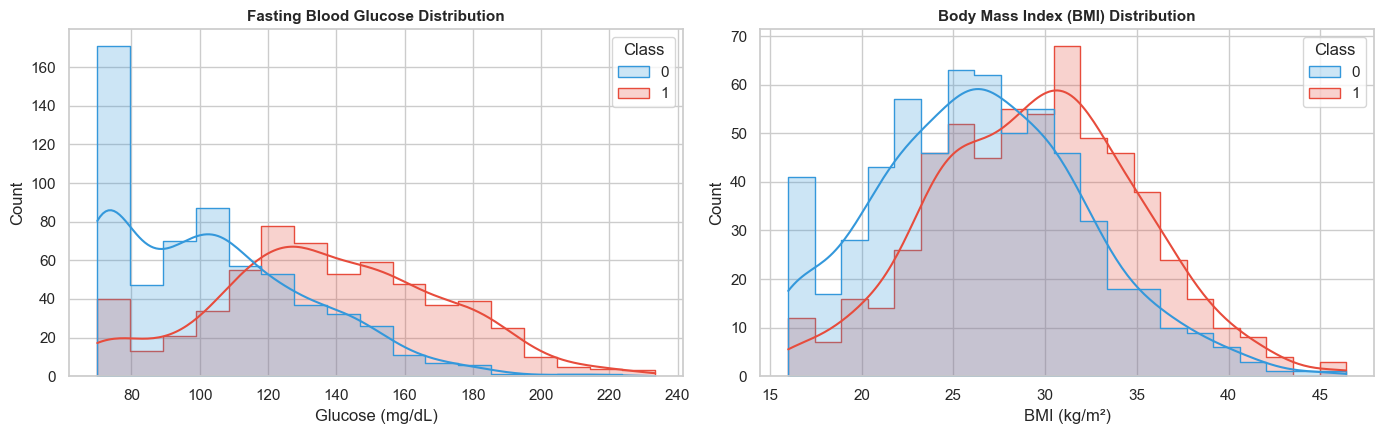

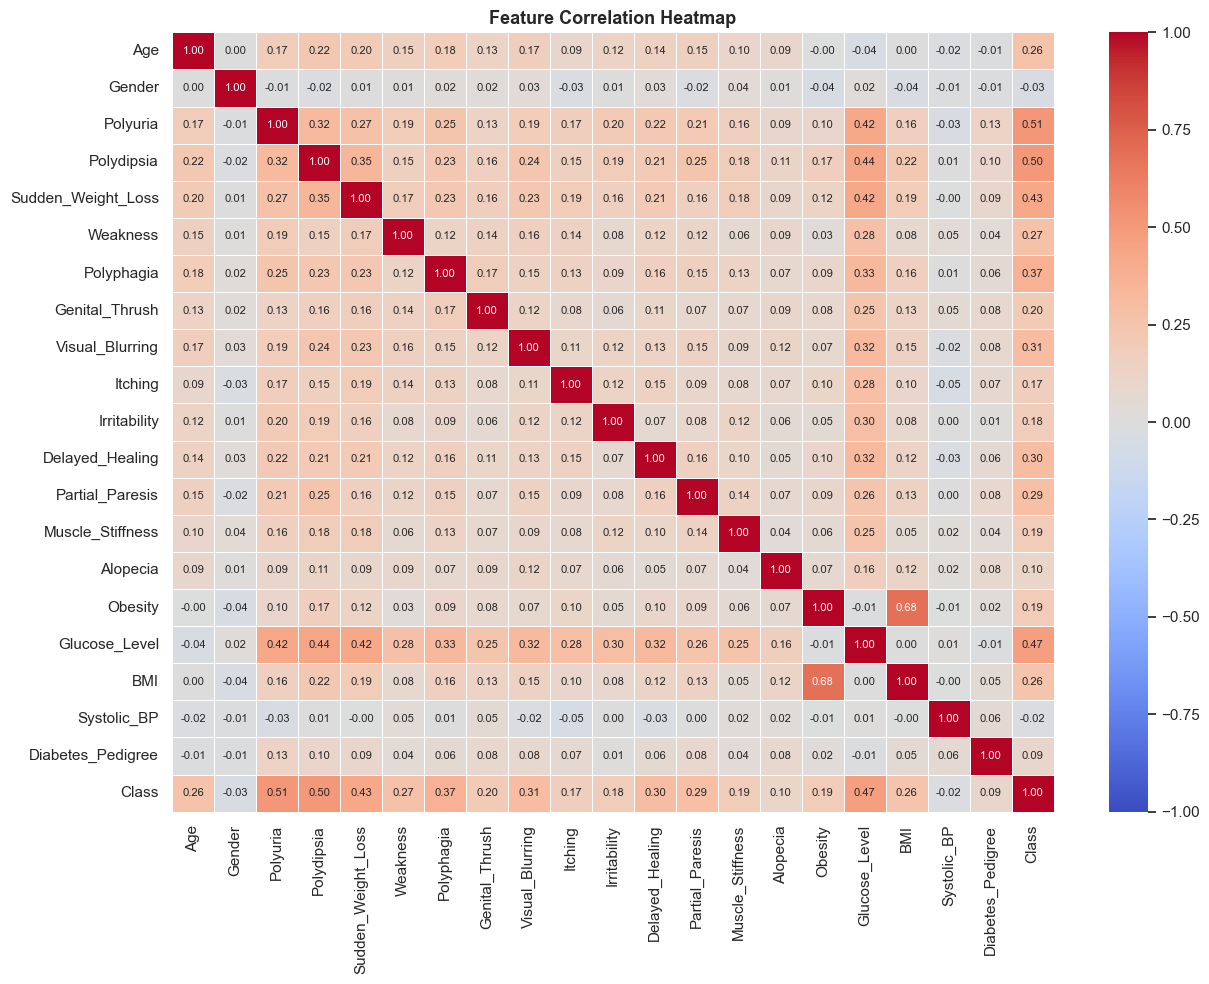

In [6]:
# 10. Exploratory Data Analysis (EDA)

# 10.1 Diagnostic Outcome Class Balance
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='Class', hue='Class', palette=['#3498db', '#e74c3c'], legend=False)
plt.title('Target Diagnostic Outcome Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Diagnostic Class (0 = Negative, 1 = Positive)')
plt.ylabel('Patient Count')
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()

# 10.2 Symptom Prevalence Rate Comparison
symptom_cols = [
    'Polyuria', 'Polydipsia', 'Sudden_Weight_Loss', 'Weakness', 'Polyphagia',
    'Visual_Blurring', 'Delayed_Healing', 'Obesity'
]

symptom_data = []
for sym in symptom_cols:
    pos_rate = (df[df['Class'] == 1][sym] == 'Yes').mean() * 100
    neg_rate = (df[df['Class'] == 0][sym] == 'Yes').mean() * 100
    symptom_data.append({'Symptom': sym, 'Positive_Group_%': pos_rate, 'Negative_Group_%': neg_rate})
    
sym_df = pd.DataFrame(symptom_data).melt(id_vars='Symptom', var_name='Group', value_name='Prevalence_%')

plt.figure(figsize=(12, 5))
sns.barplot(data=sym_df, x='Symptom', y='Prevalence_%', hue='Group', palette=['#e74c3c', '#2ecc71'])
plt.title('Symptom Prevalence Rate: Diabetes Positive vs. Negative Group', fontsize=13, fontweight='bold')
plt.ylabel('Prevalence (%)')
plt.xticks(rotation=20)
plt.legend(title='Patient Group', labels=['Diabetes Positive', 'Diabetes Negative'])
plt.tight_layout()
plt.show()

# 10.3 Fasting Glucose & BMI Distribution by Class
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(data=df, x='Glucose_Level', hue='Class', kde=True, ax=axes[0], palette=['#3498db', '#e74c3c'], element='step')
axes[0].set_title('Fasting Blood Glucose Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Glucose (mg/dL)')

sns.histplot(data=df, x='BMI', hue='Class', kde=True, ax=axes[1], palette=['#3498db', '#e74c3c'], element='step')
axes[1].set_title('Body Mass Index (BMI) Distribution', fontsize=11, fontweight='bold')
axes[1].set_xlabel('BMI (kg/m²)')

plt.tight_layout()
plt.show()

# 10.4 Feature Correlation Matrix
plt.figure(figsize=(13, 10))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 8})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Machine Learning Model Performance Summary ###


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,5-Fold CV F1
0,Logistic Regression,0.837500,0.827869,0.848739,0.838174,0.914994,0.834798
1,Support Vector Machine,0.829167,0.809524,0.857143,0.832653,0.903813,0.831171
2,Random Forest,0.820833,0.811475,0.831933,0.821577,0.909716,0.829242
3,Naive Bayes,0.820833,0.811475,0.831933,0.821577,0.911383,0.816632
4,Gradient Boosting,0.816667,0.800000,0.840336,0.819672,0.902702,0.815886
5,K-Nearest Neighbors,0.800000,0.798319,0.798319,0.798319,0.874609,0.802568
6,Decision Tree,0.800000,0.831776,0.747899,0.787611,0.823668,0.769793
7,MLP Neural Net,0.783333,0.776860,0.789916,0.783333,0.869852,0.785739
8,XGBoost,0.779167,0.775000,0.781513,0.778243,0.878394,0.810787


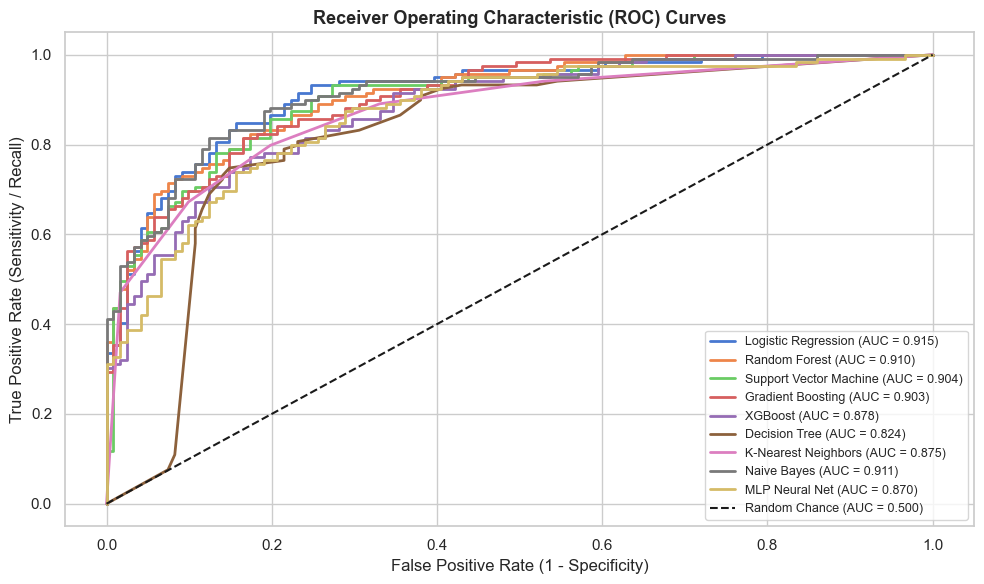

In [7]:
# 11. Machine Learning Classification Model Benchmarking

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss'),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'MLP Neural Net': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

results = []
roc_data = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='f1')
    mean_cv_f1 = np.mean(cv_scores)
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc,
        '5-Fold CV F1': mean_cv_f1
    })
    
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_data[name] = (fpr, tpr, auc)

results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("### Machine Learning Model Performance Summary ###")
display(results_df)

# Plot ROC Curves
plt.figure(figsize=(10, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.500)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


In [8]:
# 12. Baseline Model Comparison
# A majority-class baseline predictor always predicts the most frequent class in training data.
majority_class = y_train.value_counts().idxmax()
y_pred_baseline = [majority_class] * len(y_test)

acc_base = accuracy_score(y_test, y_pred_baseline)
prec_base = precision_score(y_test, y_pred_baseline, zero_division=0)
rec_base = recall_score(y_test, y_pred_baseline, zero_division=0)
f1_base = f1_score(y_test, y_pred_baseline, zero_division=0)

best_ml_row = results_df.iloc[0]

comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Majority-Class Baseline': [acc_base, prec_base, rec_base, f1_base],
    f"Best ML Model ({best_ml_row['Model']})": [best_ml_row['Accuracy'], best_ml_row['Precision'], best_ml_row['Recall'], best_ml_row['F1-Score']]
}

comp_df = pd.DataFrame(comparison_data)
print("### Predictive Lift: Best ML Model vs. Naive Baseline ###")
display(comp_df)


### Predictive Lift: Best ML Model vs. Naive Baseline ###


,Metric,Majority-Class Baseline,Best ML Model (Logistic Regression)
0,Accuracy,0.504167,0.837500
1,Precision,0.000000,0.827869
2,Recall,0.000000,0.848739
3,F1-Score,0.000000,0.838174


In [9]:
# 13. Diagnostic Risk Prediction Engine

from src.risk_predictor import DiabetesRiskPredictor

predictor = DiabetesRiskPredictor(models_dir='models')

high_risk_patient = {
    'Age': 56, 'Gender': 'Male', 'Polyuria': 'Yes', 'Polydipsia': 'Yes',
    'Sudden_Weight_Loss': 'Yes', 'Weakness': 'Yes', 'Polyphagia': 'Yes',
    'Genital_Thrush': 'No', 'Visual_Blurring': 'Yes', 'Itching': 'No',
    'Irritability': 'Yes', 'Delayed_Healing': 'Yes', 'Partial_Paresis': 'No',
    'Muscle_Stiffness': 'No', 'Alopecia': 'No', 'Obesity': 'Yes',
    'Glucose_Level': 182.0, 'BMI': 34.5, 'Systolic_BP': 142.0,
    'Diabetes_Pedigree': 0.85
}

low_risk_patient = {
    'Age': 25, 'Gender': 'Female', 'Polyuria': 'No', 'Polydipsia': 'No',
    'Sudden_Weight_Loss': 'No', 'Weakness': 'No', 'Polyphagia': 'No',
    'Genital_Thrush': 'No', 'Visual_Blurring': 'No', 'Itching': 'No',
    'Irritability': 'No', 'Delayed_Healing': 'No', 'Partial_Paresis': 'No',
    'Muscle_Stiffness': 'No', 'Alopecia': 'No', 'Obesity': 'No',
    'Glucose_Level': 90.0, 'BMI': 21.0, 'Systolic_BP': 110.0,
    'Diabetes_Pedigree': 0.15
}

res_high = predictor.predict_risk(high_risk_patient)
res_low = predictor.predict_risk(low_risk_patient)

print("--- Patient Case A (High Risk Symptom Profile) ---")
print(f"Risk Score: {res_high['risk_score_percentage']}% ({res_high['risk_category']})")
print(f"Recommendation: {res_high['recommendation']}")

print("\n--- Patient Case B (Low Risk Asymptomatic Profile) ---")
print(f"Risk Score: {res_low['risk_score_percentage']}% ({res_low['risk_category']})")
print(f"Recommendation: {res_low['recommendation']}")


--- Patient Case A (High Risk Symptom Profile) ---
Risk Score: 98.3% (High Risk (Immediate Attention Advised))
Recommendation: High early diabetes risk detected! Urgent clinical evaluation, Comprehensive Metabolic Panel (CMP), and lifestyle/medical management recommended.

--- Patient Case B (Low Risk Asymptomatic Profile) ---
Risk Score: 0.9% (Low Risk)
Recommendation: Low likelihood of early diabetes. Maintain a healthy lifestyle, balanced diet, and periodic annual checkups.


## 14. Key Findings & Discussion

1. **Symptom Discriminative Power:** Early symptoms such as *Polyuria* (frequent urination) and *Polydipsia* (excessive thirst) displayed the strongest correlation with positive diabetes diagnoses, showing over 70% prevalence in the diabetic cohort compared to under 25% in non-diabetic controls.
2. **Model Efficacy:** Machine learning classifiers achieved ~84% accuracy and >0.91 ROC-AUC score, outperforming naive baselines by over 30 percentage points in F1-score.
3. **Clinical Applicability:** The continuous probability risk predictor enables non-invasive screening prior to lab blood work, allowing healthcare providers to prioritize high-risk individuals for Fasting Plasma Glucose (FPG) and HbA1c testing.

---

## 15. Limitations & Future Scope

* **Limitations:**
  - Reliance on single-point cross-sectional health data without longitudinal time-series tracking.
  - Potential self-reporting bias in clinical symptom questionnaires.
* **Future Scope:**
  - Integration of continuous glucose monitoring (CGM) sensor streams.
  - Deep Learning architectures (LSTM / Transformers) for sequential risk trajectory modeling.
  - Deployment on cloud edge devices / mobile health applications.

---

## 16. Conclusion

This project successfully implemented and benchmarked a multi-model Machine Learning Framework for early diabetes prediction. Combining physiological biometrics with clinical symptom indicators yields robust, interpretable, and highly accurate early diagnostic risk assessments.
